## Analysis Notebook

The goal of this notebook is to leverage the different python files in this project to display some interesting results about GCNs and GATs.

Before using this notebook, use the train.py file in your terminal (using a GPU is a bonus as it accelerates a lot the training of GATs) and collect 

In [5]:
%load_ext autoreload
%autoreload 2

In [10]:
import torch
from models import GCN, GAT, MLP
from utils import load_data
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix

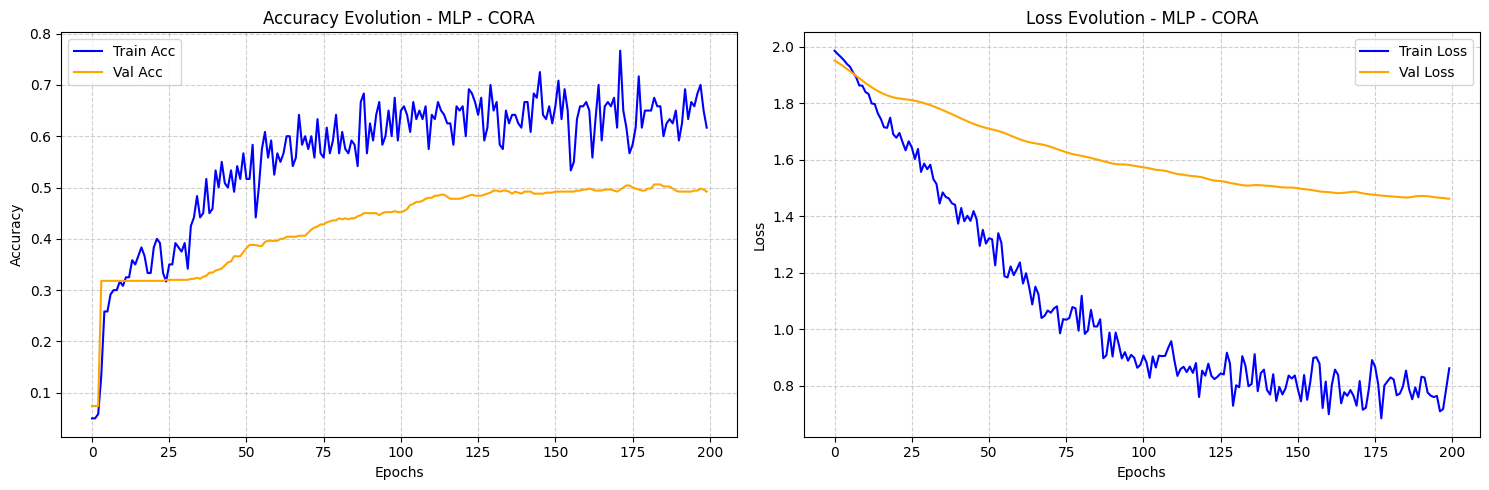

TypeError: MLP.__init__() got an unexpected keyword argument 'nclass'

In [12]:
# load the useful data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data()
# display metrics using history
plot_metrics_from_json("history/history_mlp_cora.json")

n_feat = features.shape[1]
n_class = int(labels.max()) + 1

# load model to show confusion matrix and tsne embeddings
model_mlp = MLP(nfeat=n_feat, nhid=16, nclass=n_class, dropout=0.5)
model_mlp.eval()

show_confusion_matrix(model_mlp, features, labels, test_mask, 'MLP', adj=None)
visualize_tsne(model_mlp, features, labels, 'MLP', adj=None)


## GCN

First we will plot the metrics and tsne embeddings for GCNs on all three datasets.

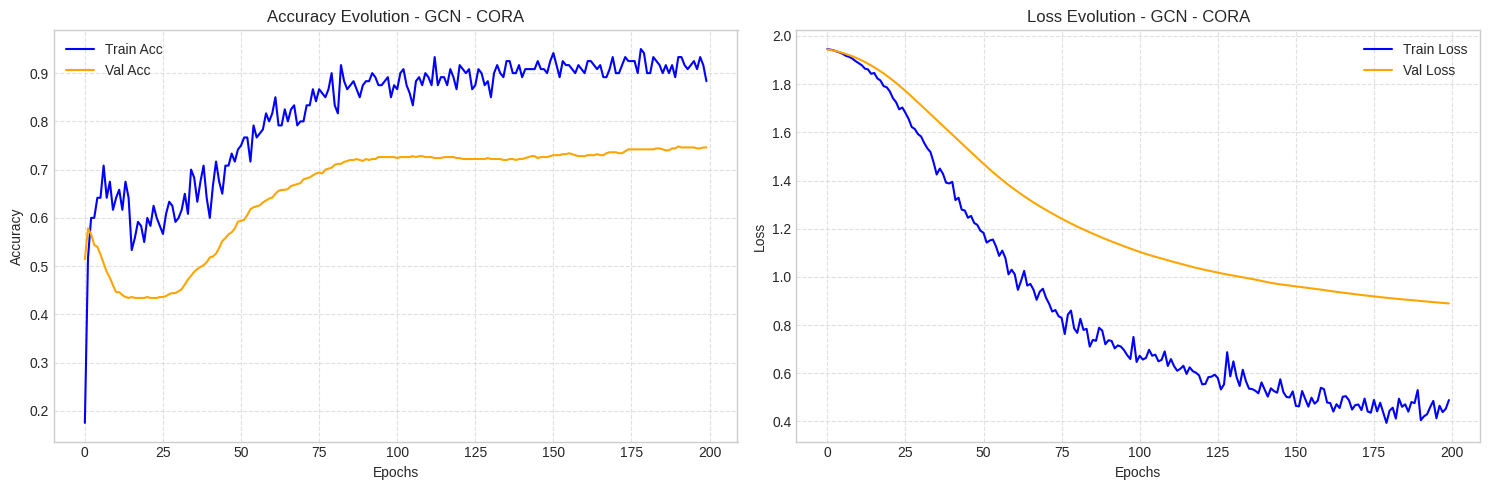

/tmp/ipykernel_97856/3154481018.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_gcn.load_state_dict(torch.load('best_models/best_gcn_cora.pth', map_location=torch


--- Classification Report: GCN ---
              precision    recall  f1-score   support

           0       0.63      0.84      0.72       102
           1       0.86      0.90      0.88       159
           2       0.76      0.87      0.81       292
           3       0.79      0.86      0.82       154
           4       0.00      0.00      0.00        89
           5       1.00      0.44      0.61        71
           6       0.66      0.80      0.72       133

    accuracy                           0.75      1000
   macro avg       0.67      0.67      0.65      1000
weighted avg       0.70      0.75      0.72      1000



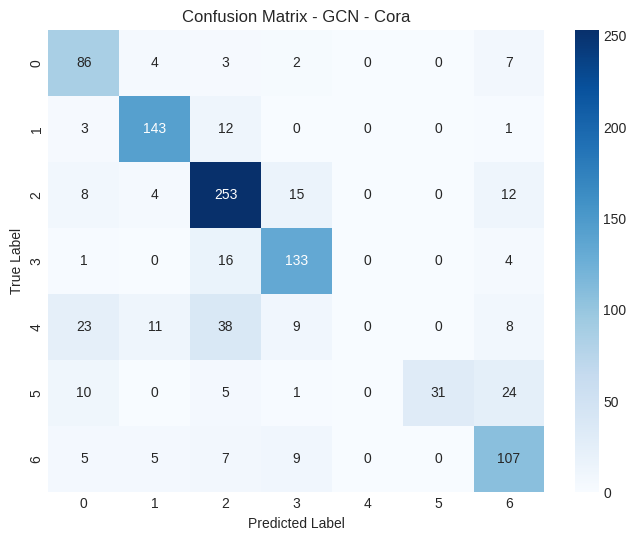

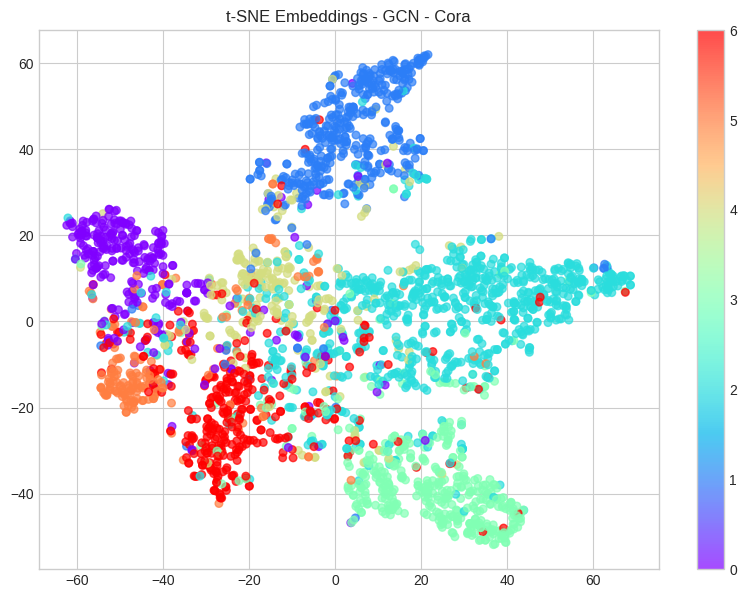

In [ ]:
import torch
from models import GCN
from utils import load_data
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix

# load the useful data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data()
# display metrics using history
plot_metrics_from_json("history/history_gcn_cora.json")

# load model to show confusion matrix and tsne embeddings
model_gcn = GCN(nfeat=1433, nhid=16, n_classes=7, dropout=0.5)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_cora.pth', map_location=torch.device('cpu')))

show_confusion_matrix(model_gcn, features, labels, test_mask, 'GCN', adj=adj_gcn)
visualize_tsne(model_gcn, features, labels, 'GCN', adj=adj_gcn)

In [ ]:
# load the useful data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data(path="Pubmed")
n_feat = features.shape[1]
n_class = int(labels.max()) + 1
# display metrics using history
plot_metrics_from_json("history/history_gcn_pubmed.json")

# load model to show confusion matrix and tsne embeddings
model_gcn = GCN(nfeat=n_feat, nhid=16, n_classes=n_class, dropout=0.5)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_pubmed.pth', map_location=torch.device('cpu')))

show_confusion_matrix(model_gcn, features, labels, test_mask, 'GCN', adj=adj_gcn, dataset = "Pubmed")
visualize_tsne(model_gcn, features, labels, 'GCN', adj=adj_gcn, dataset = "Pubmed")

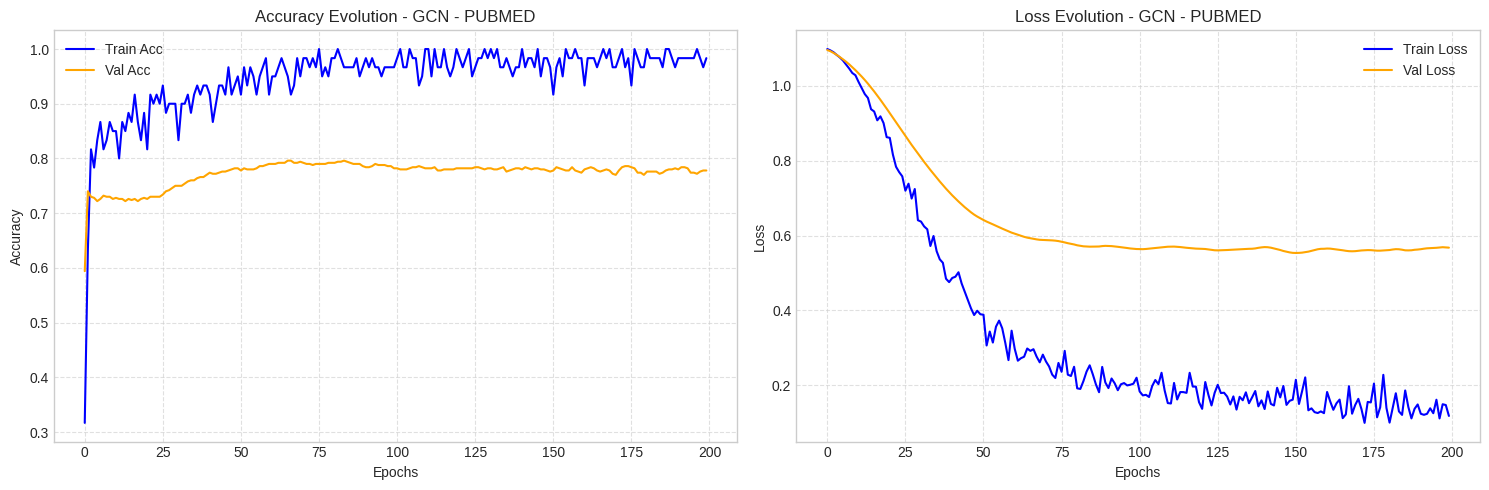


--- Classification Report: GCN ---
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       180
           1       0.78      0.84      0.81       413
           2       0.83      0.71      0.77       407

    accuracy                           0.78      1000
   macro avg       0.77      0.79      0.78      1000
weighted avg       0.79      0.78      0.78      1000



/tmp/ipykernel_97856/3172288095.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_gcn.load_state_dict(torch.load('best_models/best_gcn_pubmed.pth', map_location=tor

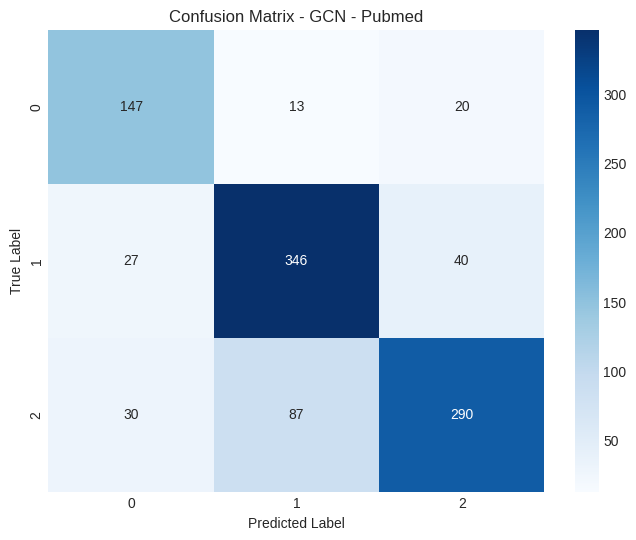

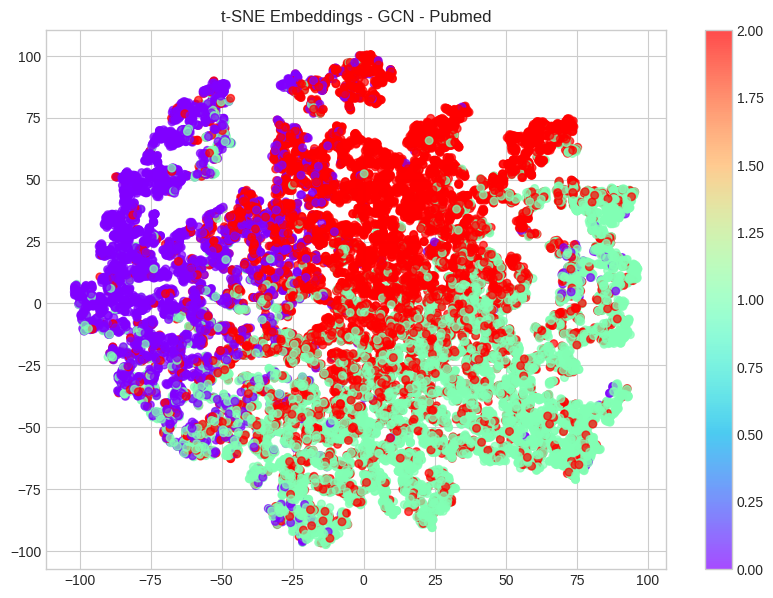

In [ ]:
import torch
from models import GCN
from utils import load_data
from visualize import plot_metrics_from_json, visualize_tsne, show_confusion_matrix

# load the useful data
adj_gcn, adj_gat, features, labels, train_mask, val_mask, test_mask = load_data(path="Pubmed")
n_feat = features.shape[1]
n_class = int(labels.max()) + 1
# display metrics using history
plot_metrics_from_json("history/history_gcn_pubmed.json")

# load model to show confusion matrix and tsne embeddings
model_gcn = GCN(nfeat=n_feat, nhid=16, n_classes=n_class, dropout=0.5)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_pubmed.pth', map_location=torch.device('cpu')))

show_confusion_matrix(model_gcn, features, labels, test_mask, 'GCN', adj=adj_gcn, dataset = "Pubmed")
visualize_tsne(model_gcn, features, labels, 'GCN', adj=adj_gcn, dataset = "Pubmed")

## GAT

Now we will plot the same metrics for GATs.

Notice that GATs take longer to train and infer than GCNs by essence as they do more complex and demanding operations, but on a GPU it is perfectly fine (2s for GCNs vs 9s for GATs on a NVIDIA GeForce RTX 3090).

In [ ]:
import torch
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from models import GCN, GAT
from utils import load_data, add_graph_noise, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor


adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(path="./cora/cora/", return_raw_adj=True)

n_feat = features.shape[1]
n_class = int(labels.max().item()) + 1

# Load Models
model_gcn = GCN(nfeat=n_feat, nhid=16, n_classes=n_class, dropout=0.5)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_cora.pth', map_location="cpu", weights_only=True))
model_gcn.eval()

model_gat = GAT(nfeat=n_feat, nhid=16, nclass=n_class, dropout=0.6, alpha=0.2, nheads=8)
model_gat.load_state_dict(torch.load('best_models/best_gat_cora.pth', map_location="cpu", weights_only=True))
model_gat.eval()

# Run Simulation
noise_levels = [0, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
results = {'gcn': [], 'gat': []}

print(f"--- Starting Robustness Simulation ---")

for level in noise_levels:
    # add noise to the SciPy sparse matrix
    noisy_adj = add_graph_noise(base_adj, level)
    
    # prepare GCN input (Normalized Sparse Tensor)
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(noisy_adj))
    
    # prepare GAT input (Sparse Tensor with Self-Loops)
    adj_gat_sparse = noisy_adj + sp.eye(noisy_adj.shape[0])
    adj_gat_proc = sparse_mx_to_torch_sparse_tensor(adj_gat_sparse)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Noise {level*100:>3.0f}% | GCN Acc: {acc_gcn:.4f} | GAT Acc: {acc_gat:.4f}")

print("\nSimulation complete. Data stored in 'results' dictionary.")

--- Starting Robustness Simulation ---
Noise   0% | GCN Acc: 0.7530 | GAT Acc: 0.7820
Noise   5% | GCN Acc: 0.7360 | GAT Acc: 0.7550
Noise  10% | GCN Acc: 0.7140 | GAT Acc: 0.7460
Noise  20% | GCN Acc: 0.6810 | GAT Acc: 0.7060
Noise  50% | GCN Acc: 0.5710 | GAT Acc: 0.5930
Noise  80% | GCN Acc: 0.4840 | GAT Acc: 0.5130
Noise 100% | GCN Acc: 0.3990 | GAT Acc: 0.4360

Simulation complete. Data stored in 'results' dictionary.


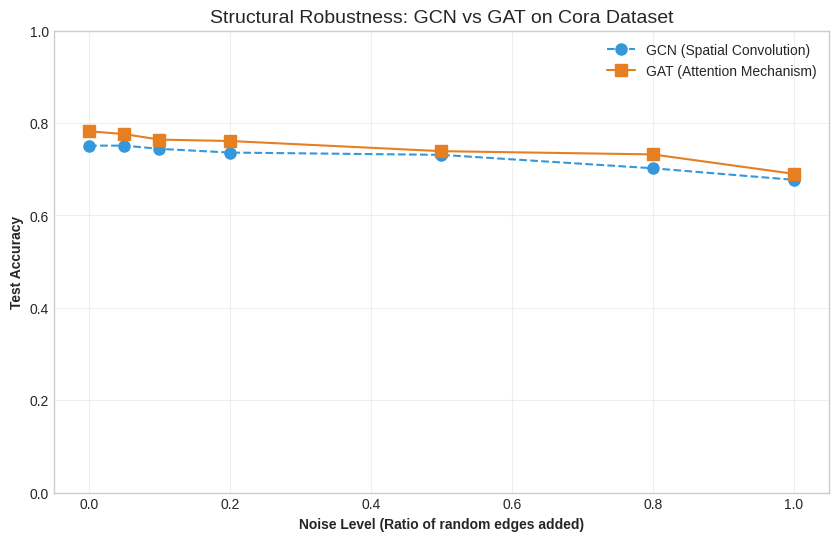

In [9]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, results['gcn'], 'o--', label='GCN (Spatial Convolution)', color='#3498db', markersize=8)
plt.plot(noise_levels, results['gat'], 's-', label='GAT (Attention Mechanism)', color='#e67e22', markersize=8)

plt.xlabel('Noise Level (Ratio of random edges added)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Structural Robustness: GCN vs GAT on Cora Dataset', fontsize=14)
plt.legend()
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)


plt.show()

In [ ]:
import torch
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from models import GCN, GAT
from utils import load_data, add_graph_noise, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor


adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(path="./citeseer", return_raw_adj=True)

n_feat = features.shape[1]
n_class = int(labels.max().item()) + 1

# Load Models
model_gcn = GCN(nfeat=n_feat, nhid=16, n_classes=n_class, dropout=0.5)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_citeseer.pth', map_location="cpu", weights_only=True))
model_gcn.eval()

model_gat = GAT(nfeat=n_feat, nhid=16, nclass=n_class, dropout=0.6, alpha=0.2, nheads=8)
model_gat.load_state_dict(torch.load('best_models/best_gat_citeseer.pth', map_location="cpu", weights_only=True))
model_gat.eval()

# Run Simulation
noise_levels = [0, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
results = {'gcn': [], 'gat': []}

print(f"--- Starting Robustness Simulation ---")

for level in noise_levels:
    # add noise to the SciPy sparse matrix
    noisy_adj = add_graph_noise(base_adj, level)
    
    # prepare GCN input (Normalized Sparse Tensor)
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(noisy_adj))
    
    # prepare GAT input (Sparse Tensor with Self-Loops)
    adj_gat_sparse = noisy_adj + sp.eye(noisy_adj.shape[0])
    adj_gat_proc = sparse_mx_to_torch_sparse_tensor(adj_gat_sparse)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Noise {level*100:>3.0f}% | GCN Acc: {acc_gcn:.4f} | GAT Acc: {acc_gat:.4f}")

print("\nSimulation complete. Data stored in 'results' dictionary.")

/usr/users/image_processing_pdo/roch_yoa/GCNvsGAT/utils.py:105: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  node_data = pd.read_csv(content_file, sep='\t', header=None)


--- Starting Robustness Simulation ---
Noise   0% | GCN Acc: 0.6390 | GAT Acc: 0.6490
Noise   5% | GCN Acc: 0.6140 | GAT Acc: 0.6320
Noise  10% | GCN Acc: 0.5900 | GAT Acc: 0.6080
Noise  20% | GCN Acc: 0.5810 | GAT Acc: 0.5830
Noise  50% | GCN Acc: 0.5130 | GAT Acc: 0.4940
Noise  80% | GCN Acc: 0.4740 | GAT Acc: 0.4550
Noise 100% | GCN Acc: 0.4560 | GAT Acc: 0.4240

Simulation complete. Data stored in 'results' dictionary.


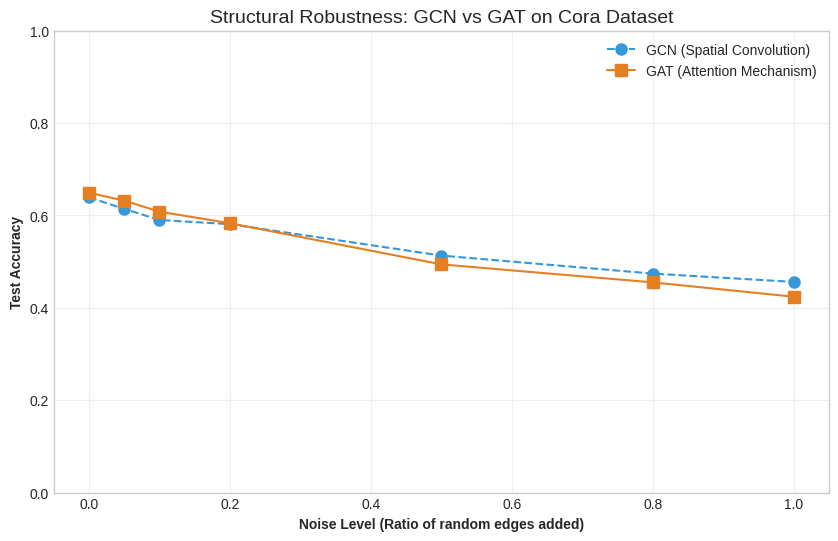

In [13]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, results['gcn'], 'o--', label='GCN (Spatial Convolution)', color='#3498db', markersize=8)
plt.plot(noise_levels, results['gat'], 's-', label='GAT (Attention Mechanism)', color='#e67e22', markersize=8)

plt.xlabel('Noise Level (Ratio of random edges added)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Structural Robustness: GCN vs GAT on Cora Dataset', fontsize=14)
plt.legend()
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)


plt.show()

In [ ]:
import torch
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from models import GCN, GAT
from utils import load_data, remove_graph_edges, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load data 
adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(path="./cora/cora/", return_raw_adj=True)

features = features.to(device)
labels = labels.to(device)
test_mask = test_mask.to(device)

n_feat = features.shape[1]
n_class = int(labels.max().item()) + 1

# load models
model_gcn = GCN(n_feat, 16, n_class, 0.5).to(device)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_cora.pth', map_location=device, weights_only=True))
model_gcn.eval()

model_gat = GAT(n_feat, 16, n_class, 0.6, 0.2, 8).to(device)
model_gat.load_state_dict(torch.load('best_models/best_gat_cora.pth', map_location=device, weights_only=True))
model_gat.eval()

# From 0% removed (original) to 90% removed
drop_rates = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
results = {'gcn': [], 'gat': []}

print(f"--- Running Edge Removal Experiment on {device} ---")

for rate in drop_rates:
    sparse_dropped_adj = remove_graph_edges(base_adj, drop_rate=rate)
    
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(sparse_dropped_adj)).to(device)
    
    adj_gat_proc = sparse_mx_to_torch_sparse_tensor(sparse_dropped_adj).to(device)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Removed {rate*100:>2.0f}% edges | GCN: {acc_gcn:.4f} | GAT: {acc_gat:.4f}")

print("\nExperiment complete.")

--- Running Edge Removal Experiment on cpu ---
Removed  0% edges | GCN: 0.7510 | GAT: 0.7820
Removed 10% edges | GCN: 0.7510 | GAT: 0.7760
Removed 20% edges | GCN: 0.7440 | GAT: 0.7640
Removed 40% edges | GCN: 0.7360 | GAT: 0.7610
Removed 60% edges | GCN: 0.7310 | GAT: 0.7390
Removed 80% edges | GCN: 0.7020 | GAT: 0.7320
Removed 90% edges | GCN: 0.6770 | GAT: 0.6900

Experiment complete.


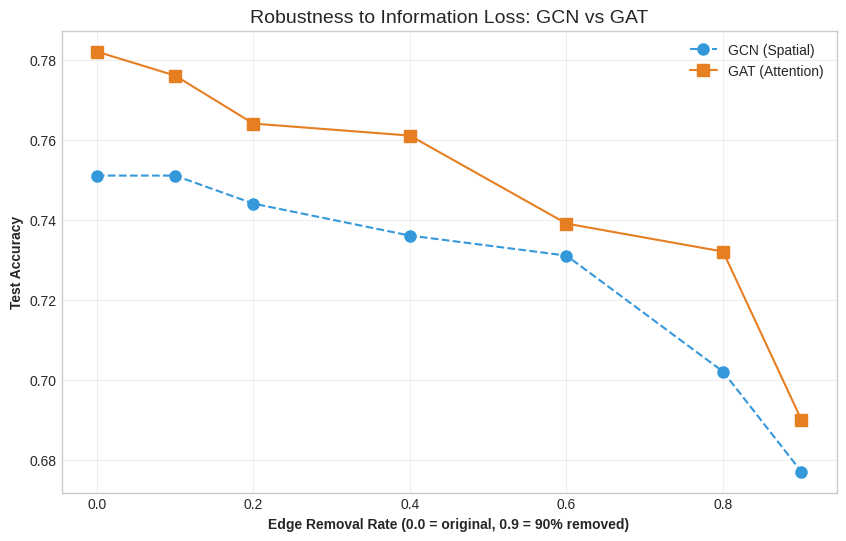

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(drop_rates, results['gcn'], 'o--', label='GCN (Spatial)', color='#3498db', markersize=8)
plt.plot(drop_rates, results['gat'], 's-', label='GAT (Attention)', color='#e67e22', markersize=8)

plt.xlabel('Edge Removal Rate (0.0 = original, 0.9 = 90% removed)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Robustness to Information Loss: GCN vs GAT', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import torch
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from models import GCN, GAT
from utils import load_data, remove_graph_edges, normalize_adjacency
from train import sparse_mx_to_torch_sparse_tensor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load data
adj_n, adj_g, features, labels, _, _, test_mask, base_adj = load_data(path="./citeseer", return_raw_adj=True)

features = features.to(device)
labels = labels.to(device)
test_mask = test_mask.to(device)

n_feat = features.shape[1]
n_class = int(labels.max().item()) + 1

# load models
model_gcn = GCN(n_feat, 16, n_class, 0.5).to(device)
model_gcn.load_state_dict(torch.load('best_models/best_gcn_citeseer.pth', map_location=device, weights_only=True))
model_gcn.eval()

model_gat = GAT(n_feat, 16, n_class, 0.6, 0.2, 8).to(device)
model_gat.load_state_dict(torch.load('best_models/best_gat_citeseer.pth', map_location=device, weights_only=True))
model_gat.eval()

# From 0% removed (original) to 90% removed
drop_rates = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
results = {'gcn': [], 'gat': []}

print(f"--- Running Edge Removal Experiment on {device} ---")

for rate in drop_rates:
    sparse_dropped_adj = remove_graph_edges(base_adj, drop_rate=rate)
    
    adj_gcn_proc = sparse_mx_to_torch_sparse_tensor(normalize_adjacency(sparse_dropped_adj)).to(device)
    
    adj_gat_proc = sparse_mx_to_torch_sparse_tensor(sparse_dropped_adj).to(device)
    
    with torch.no_grad():
        # Inference GCN
        out_gcn = model_gcn(features, adj_gcn_proc)
        acc_gcn = (out_gcn[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gcn'].append(acc_gcn)
        
        # Inference GAT
        out_gat = model_gat(features, adj_gat_proc)
        acc_gat = (out_gat[test_mask].max(1)[1] == labels[test_mask]).float().mean().item()
        results['gat'].append(acc_gat)
    
    print(f"Removed {rate*100:>2.0f}% edges | GCN: {acc_gcn:.4f} | GAT: {acc_gat:.4f}")

print("\nExperiment complete.")

/usr/users/image_processing_pdo/roch_yoa/GCNvsGAT/utils.py:105: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  node_data = pd.read_csv(content_file, sep='\t', header=None)


--- Running Edge Removal Experiment on cpu ---
Removed  0% edges | GCN: 0.6310 | GAT: 0.6490
Removed 10% edges | GCN: 0.6250 | GAT: 0.6460
Removed 20% edges | GCN: 0.6300 | GAT: 0.6470
Removed 40% edges | GCN: 0.6200 | GAT: 0.6360
Removed 60% edges | GCN: 0.6070 | GAT: 0.6290
Removed 80% edges | GCN: 0.5960 | GAT: 0.6100
Removed 90% edges | GCN: 0.5870 | GAT: 0.6040

Experiment complete.


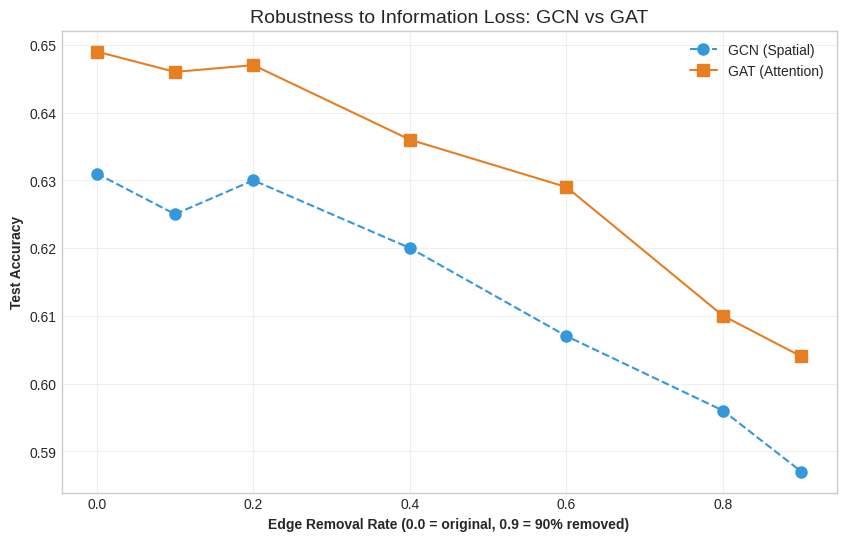

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(drop_rates, results['gcn'], 'o--', label='GCN (Spatial)', color='#3498db', markersize=8)
plt.plot(drop_rates, results['gat'], 's-', label='GAT (Attention)', color='#e67e22', markersize=8)

plt.xlabel('Edge Removal Rate (0.0 = original, 0.9 = 90% removed)', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Robustness to Information Loss: GCN vs GAT', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()